# **Data Cleaning and Preparation**
# *AltSchool Africa Data Science Second Semester Capstone Project*
## *Nigeria Power Generation Analysis*

In [1]:
## Setting up and Loading Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('nigeria_power_generation_raw.csv', parse_dates=['date'])

print("Dataset loaded!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded!
Shape: 731 rows, 5 columns

Date range: 01/01/2023 to 31/12/2024

First 5 rows:
         date  daily_generation_mwh  peak_demand_mwh  grid_frequency_hz  \
0  01/01/2023           4299.342831      5643.862081          49.706488   
1  02/01/2023           4294.237924      5924.321370          49.829050   
2  03/01/2023           3223.753620      4772.658154          50.098853   
3  04/01/2023           4583.530597      6366.377205          49.544848   
4  05/01/2023           4106.535711      6218.638928          50.225174   

   system_voltage_kv  
0         326.460450  
1         341.162786  
2         336.323191  
3         334.002276  
4         324.913166  


In [2]:
## Data Quality Assessment

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\nBasic Statistics:")
print(df.describe()) 


DATA QUALITY ASSESSMENT

Missing Values:
                      Missing Count  Percentage
daily_generation_mwh             21    2.872777
peak_demand_mwh                  21    2.872777

Basic Statistics:
       daily_generation_mwh  peak_demand_mwh  grid_frequency_hz  \
count            710.000000       710.000000         731.000000   
mean            3817.908781      5531.275546          49.986057   
std              748.966809      1135.260913           0.334321   
min              330.118054       515.717531          48.606712   
25%             3590.950992      5080.762308          49.763802   
50%             3916.816649      5648.798014          49.999906   
75%             4217.853957      6138.771861          50.215362   
max             6466.555250      9792.051991          50.860521   

       system_voltage_kv  
count         731.000000  
mean          328.311545  
std            15.385768  
min           281.031306  
25%           318.700302  
50%           328.978149  
75

### Missing Data Strategy
#### Why this matters: Missing data in electricity systems could mean equipment failure, grid collapse, or data transmission issues. We have to handle it strategically, not randomly.

In [6]:
# Forward fill for generation (equipment doesn't change capacity instantly)
df['daily_generation_mwh'] = df['daily_generation_mwh'].ffill().bfill()

# Linear interpolation for other metrics (smooth transitions expected)
df['peak_demand_mwh'] = df['peak_demand_mwh'].interpolate(method='linear')
df['grid_frequency_hz'] = df['grid_frequency_hz'].interpolate(method='linear')
df['system_voltage_kv'] = df['system_voltage_kv'].interpolate(method='linear')

print("\nMissing data handled:")
print(df.isnull().sum()) 


Missing data handled:
date                    0
daily_generation_mwh    0
peak_demand_mwh         0
grid_frequency_hz       0
system_voltage_kv       0
is_outlier              0
dtype: int64


### Outlier Detection
#### In power generation, outliers are tricky. Very low values might be actual grid collapses.
#### We use both IQR and Z-score methods, but we're conservative.

In [7]:
Q1 = df['daily_generation_mwh'].quantile(0.25)
Q3 = df['daily_generation_mwh'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Method:")
print(f"Lower bound: {lower_bound:.2f} MWh")
print(f"Upper bound: {upper_bound:.2f} MWh")

iqr_outliers = (df['daily_generation_mwh'] < lower_bound) | (df['daily_generation_mwh'] > upper_bound)
print(f"Outliers detected by IQR: {iqr_outliers.sum()}")

z_scores = np.abs((df['daily_generation_mwh'] - df['daily_generation_mwh'].mean()) / df['daily_generation_mwh'].std())
z_outliers = z_scores > 3
print(f"Outliers detected by Z-score (>3): {z_outliers.sum()}")

df['is_outlier'] = iqr_outliers & z_outliers
print(f"\nOutliers flagged by BOTH methods: {df['is_outlier'].sum()}") 


IQR Method:
Lower bound: 2660.60 MWh
Upper bound: 5151.48 MWh
Outliers detected by IQR: 49
Outliers detected by Z-score (>3): 22

Outliers flagged by BOTH methods: 22


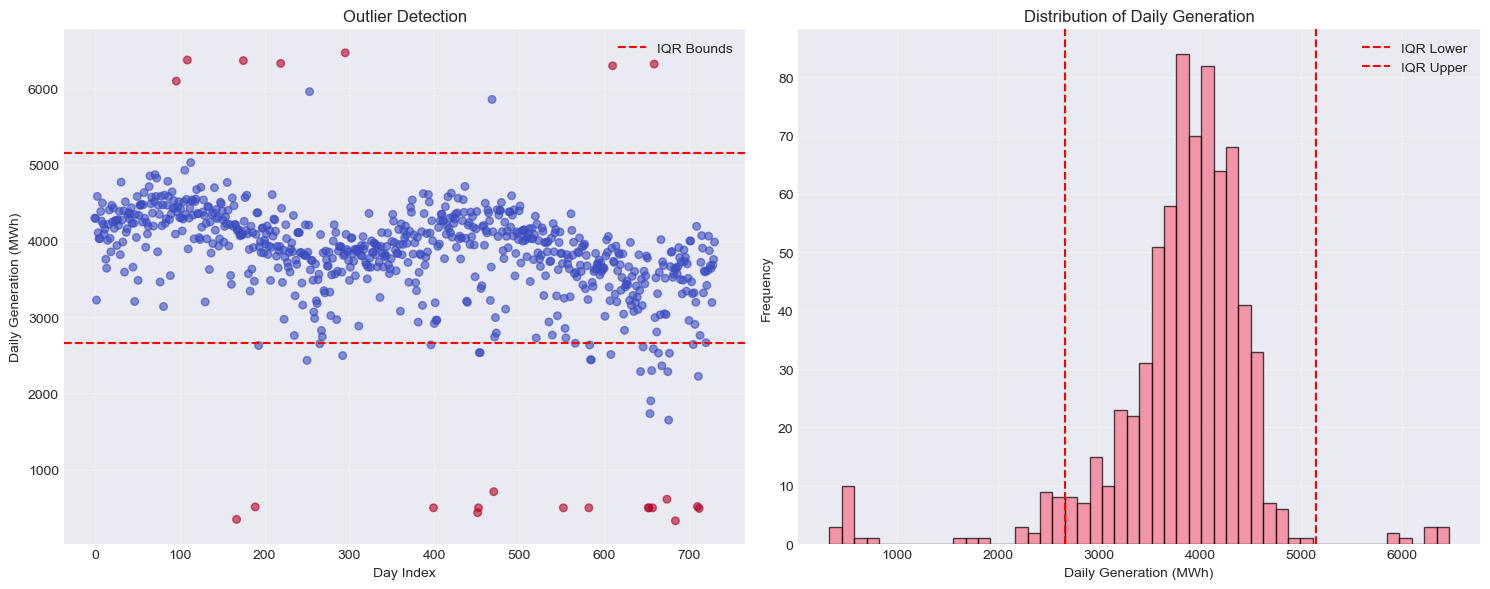

In [5]:
## Visualizing Outliers

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(df.index, df['daily_generation_mwh'], c=df['is_outlier'], 
           cmap='coolwarm', alpha=0.6, s=30)
plt.axhline(y=lower_bound, color='r', linestyle='--', label='IQR Bounds')
plt.axhline(y=upper_bound, color='r', linestyle='--')
plt.xlabel('Day Index')
plt.ylabel('Daily Generation (MWh)')
plt.title('Outlier Detection')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['daily_generation_mwh'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=lower_bound, color='r', linestyle='--', label='IQR Lower')
plt.axvline(x=upper_bound, color='r', linestyle='--', label='IQR Upper')
plt.xlabel('Daily Generation (MWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Generation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

### Handle Outliers with Capping a.k.a winsorizing
#### Why capping? We want to preserve the fact that bad days happened, just correct impossible sensor readings. Removal would bias analysis upward.

In [9]:
df_clean = df.copy()

p5 = df['daily_generation_mwh'].quantile(0.05)
p95 = df['daily_generation_mwh'].quantile(0.95)

print(f"\nCapping at 5th percentile: {p5:.2f} MWh")
print(f"Capping at 95th percentile: {p95:.2f} MWh")

df_clean.loc[df_clean['is_outlier'] & (df_clean['daily_generation_mwh'] < p5), 'daily_generation_mwh'] = p5
df_clean.loc[df_clean['is_outlier'] & (df_clean['daily_generation_mwh'] > p95), 'daily_generation_mwh'] = p95

print(f"{df['is_outlier'].sum()} outliers capped")


Capping at 5th percentile: 2639.79 MWh
Capping at 95th percentile: 4575.67 MWh
22 outliers capped


### Feature Engineering
#### Creating additional features to support analysis

In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  731 non-null    object 
 1   daily_generation_mwh  731 non-null    float64
 2   peak_demand_mwh       731 non-null    float64
 3   grid_frequency_hz     731 non-null    float64
 4   system_voltage_kv     731 non-null    float64
 5   is_outlier            731 non-null    bool   
dtypes: bool(1), float64(4), object(1)
memory usage: 29.4+ KB


In [19]:
df_clean['date'] = pd.to_datetime(df_clean['date'], dayfirst=True) 

In [20]:
df_clean['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 731 entries, 0 to 730
Series name: date
Non-Null Count  Dtype         
--------------  -----         
731 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 5.8 KB


In [21]:
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.month_name()
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['day_of_week'] = df_clean['date'].dt.day_name()

df_clean['generation_demand_gap'] = df_clean['peak_demand_mwh'] - df_clean['daily_generation_mwh']
df_clean['capacity_utilization'] = (df_clean['daily_generation_mwh'] / df_clean['peak_demand_mwh']) * 100

df_clean['frequency_out_of_range'] = (df_clean['grid_frequency_hz'] < 49.75) | (df_clean['grid_frequency_hz'] > 50.25)
df_clean['voltage_out_of_range'] = (df_clean['system_voltage_kv'] < 315) | (df_clean['system_voltage_kv'] > 345)

print("\nNew features created:")
print(df_clean.columns.tolist()) 


New features created:
['date', 'daily_generation_mwh', 'peak_demand_mwh', 'grid_frequency_hz', 'system_voltage_kv', 'is_outlier', 'year', 'month', 'month_name', 'quarter', 'day_of_week', 'generation_demand_gap', 'capacity_utilization', 'frequency_out_of_range', 'voltage_out_of_range']


### Final Quality Check

In [22]:
print("\n" + "="*60)
print("FINAL DATA QUALITY")
print("="*60)

print(f"\nTotal records: {len(df_clean)}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Days with frequency issues: {df_clean['frequency_out_of_range'].sum()}")
print(f"Days with voltage issues: {df_clean['voltage_out_of_range'].sum()}")

print("\nCleaned generation statistics:")
print(df_clean['daily_generation_mwh'].describe()) 


FINAL DATA QUALITY

Total records: 731
Missing values: 0
Days with frequency issues: 335
Days with voltage issues: 229

Cleaned generation statistics:
count     731.000000
mean     3846.260068
std       547.591406
min      1649.818545
25%      3594.681770
50%      3923.093762
75%      4217.400400
max      5957.005438
Name: daily_generation_mwh, dtype: float64


### Save Cleaned Data

In [23]:
df_clean.to_csv('nigeria_power_generation_clean.csv', index=False)
print("\nCleaned dataset saved!") 


Cleaned dataset saved!


## *Author*

### *Emmanuel Olafisoye*